Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)
Missing values in Trader Dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in Sentiment Dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows in Trader Dataset: 0
Duplicate rows in Sentiment Dataset: 0


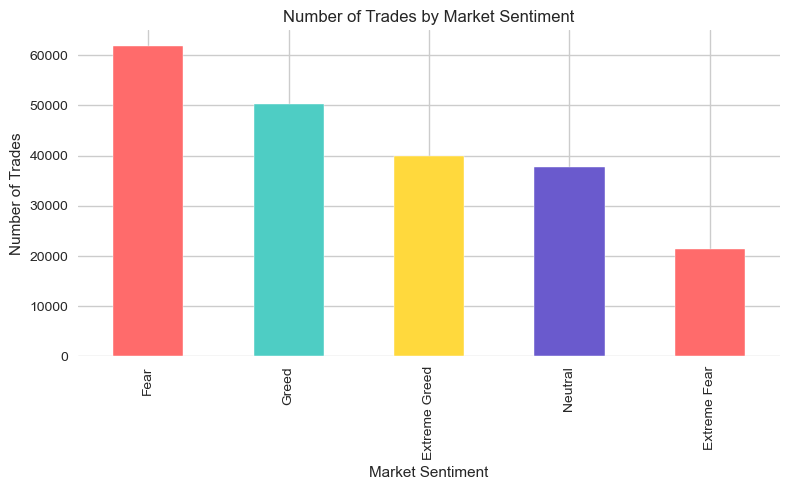

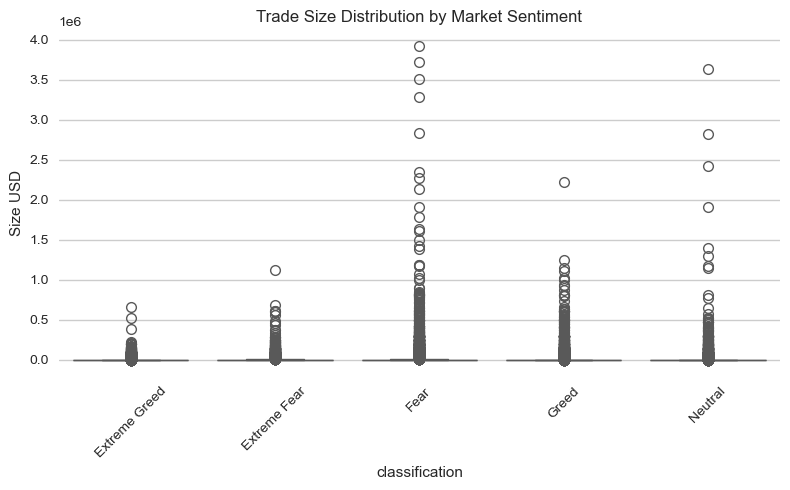

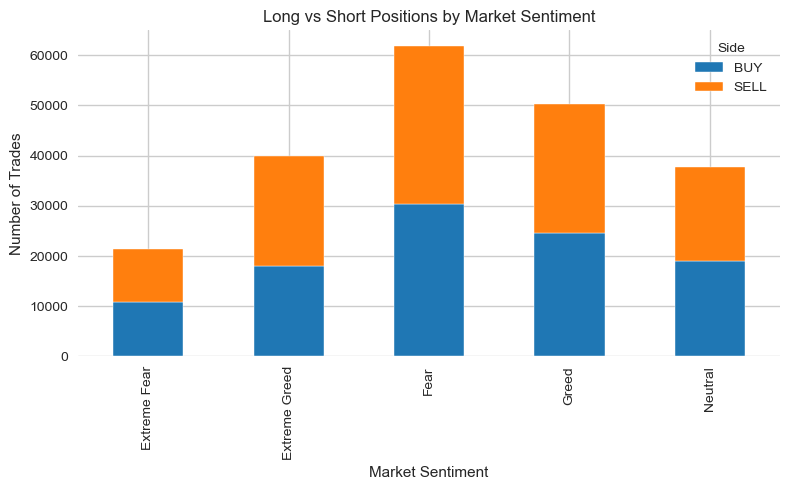

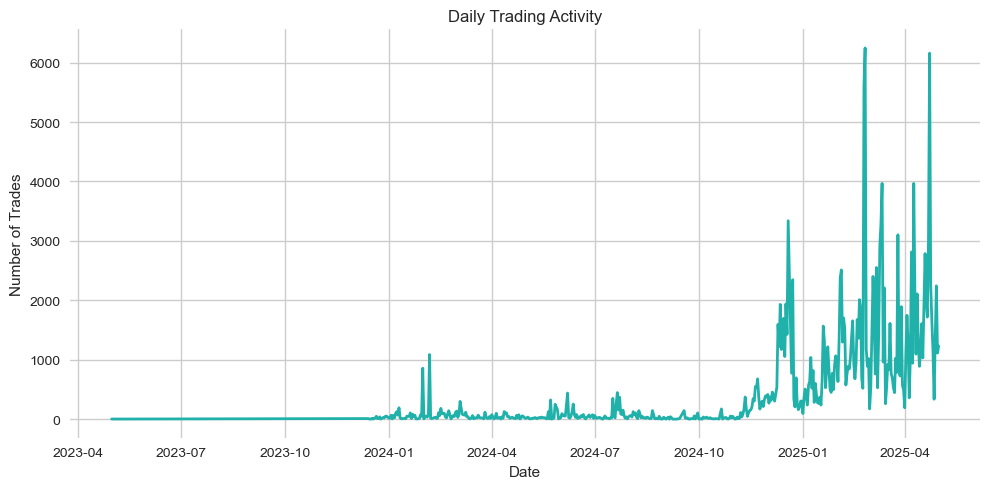

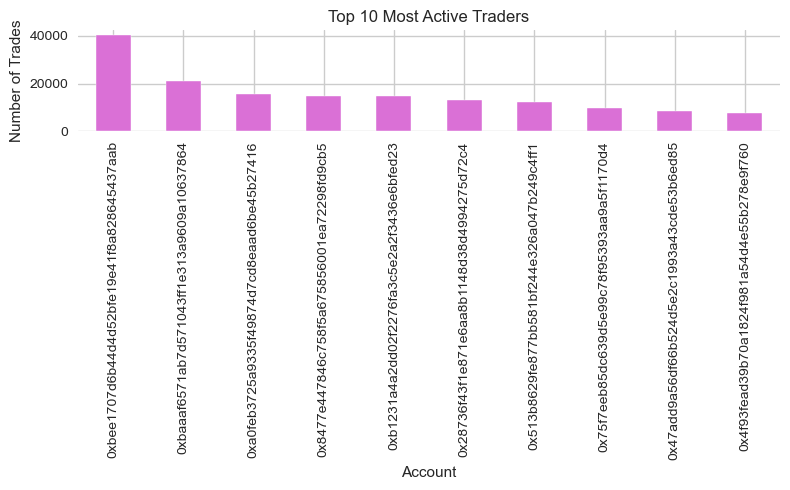

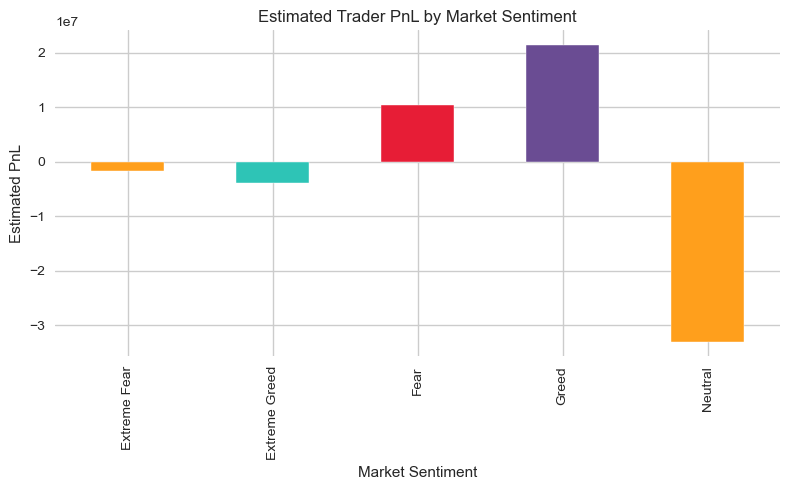

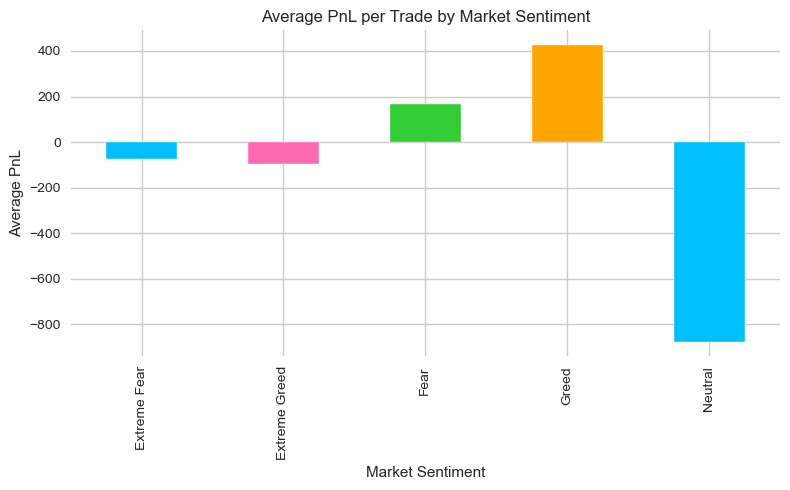

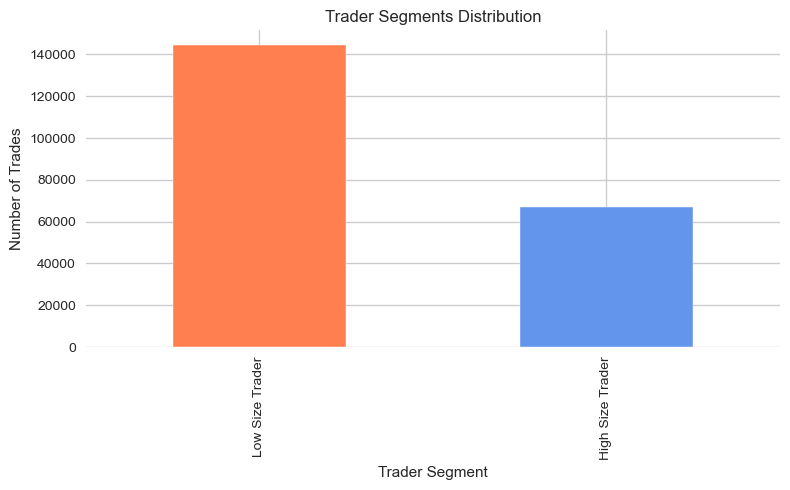

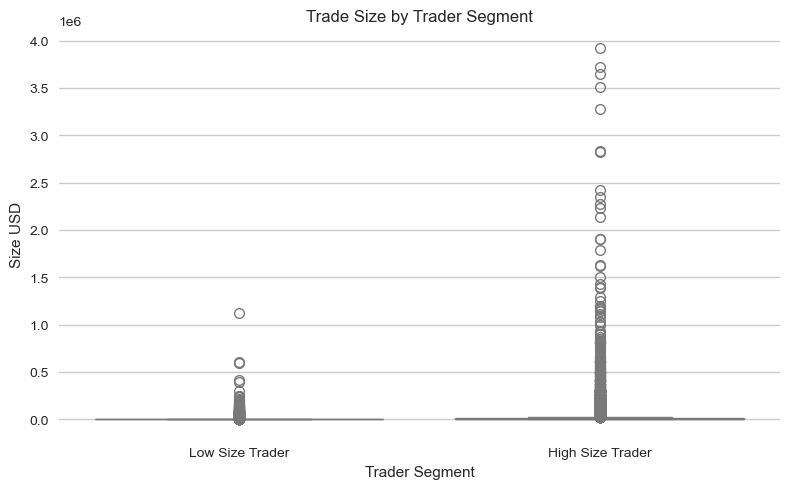

In [25]:
# Trader Performance vs Market Sentiment Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chart styling
plt.style.use("seaborn-v0_8")
sns.set_style("whitegrid")

# Data Loading

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")
print("Trader Dataset Shape:", trades.shape)
print("Sentiment Dataset Shape:", sentiment.shape)
trades.head()

# Data Cleaning

print("Missing values in Trader Dataset:")
print(trades.isnull().sum())
print("\nMissing values in Sentiment Dataset:")
print(sentiment.isnull().sum())
print("\nDuplicate rows in Trader Dataset:", trades.duplicated().sum())
print("Duplicate rows in Sentiment Dataset:", sentiment.duplicated().sum())

# Timestamp Conversion

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Dataset Merging

merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)
merged.head()

# Trading Activity by Market Sentiment

plt.figure(figsize=(8,5))
merged['classification'].value_counts().plot(
    kind='bar',
    color=['#FF6B6B','#4ECDC4','#FFD93D','#6A5ACD']
)
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.show()

# Trade Size vs Sentiment

plt.figure(figsize=(8,5))
sns.boxplot(
    x='classification',
    y='Size USD',
    hue='classification',
    data=merged,
    palette='Set2',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Trade Size Distribution by Market Sentiment")
plt.tight_layout()
plt.show()

# Long vs Short Positions

long_short = pd.crosstab(merged['classification'], merged['Side'])
long_short.plot(
    kind='bar',
    stacked=True,
    color=['#1f77b4','#ff7f0e'],
    figsize=(8,5)
)
plt.title("Long vs Short Positions by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.show()

# Daily Trading Activity

daily_trades = merged.groupby('date').size()
plt.figure(figsize=(10,5))
daily_trades.plot(
    color='#20B2AA',
    linewidth=2
)
plt.title("Daily Trading Activity")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.show()

# Top Active Traders

top_traders = merged['Account'].value_counts().head(10)
plt.figure(figsize=(8,5))
top_traders.plot(
    kind='bar',
    color='orchid'
)
plt.title("Top 10 Most Active Traders")
plt.xlabel("Account")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.show()

# Trader Performance (PnL Proxy)

merged['PnL_proxy'] = np.where(
    merged['Side'] == 'BUY',
    merged['Size USD'],
    -merged['Size USD']
)
pnl_by_sentiment = merged.groupby('classification')['PnL_proxy'].sum()
plt.figure(figsize=(8,5))
pnl_by_sentiment.plot(
    kind='bar',
    color=['#FF9F1C','#2EC4B6','#E71D36','#6A4C93']
)
plt.title("Estimated Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Estimated PnL")
plt.tight_layout()
plt.show()

# Average PnL per Trade

avg_pnl = merged.groupby('classification')['PnL_proxy'].mean()
plt.figure(figsize=(8,5))
avg_pnl.plot(
    kind='bar',
    color=['#00BFFF','#FF69B4','#32CD32','#FFA500']
)
plt.title("Average PnL per Trade by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.tight_layout()
plt.show()

# Trader Segmentation

trader_size = merged.groupby('Account')['Size USD'].mean()
median_trade_size = trader_size.median()
trader_segments = trader_size.apply(
    lambda x: 'High Size Trader' if x > median_trade_size else 'Low Size Trader'
)
merged['Trader Segment'] = merged['Account'].map(trader_segments)
plt.figure(figsize=(8,5))
merged['Trader Segment'].value_counts().plot(
    kind='bar',
    color=['#FF7F50','#6495ED']
)
plt.title("Trader Segments Distribution")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.show()

# Trade Size by Trader Segment

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Trader Segment',
    y='Size USD',
    hue='Trader Segment',
    data=merged,
    palette='coolwarm',
    legend=False
)
plt.title("Trade Size by Trader Segment")
plt.tight_layout()
plt.show()


Key Insights

- Trading activity varies across different market sentiment phases.

- Traders tend to take larger positions during Greed sentiment, indicating higher risk appetite.

- Fear sentiment shows relatively higher short-selling activity.

- A small number of traders dominate the trading volume.

Strategy Recommendations

- During Fear sentiment, traders should reduce leverage and position sizes to manage volatility.

- During Greed sentiment, momentum-based strategies may perform better due to increased long bias.

- Monitoring sentiment indicators alongside trading behavior can help identify potential market turning points.